In [1]:
pip install segmentation_models_pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 68.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.9.41
    Uninstalling nvidia-nvjitlink-cu12-12.9.41:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.9.41
  Attempting uninstall: nvidia-curand-cu12
    Found existing installation: nvidia-curand-cu12 10.3.10.19
    Uninstalling nvidia-curand-cu12-1

In [2]:
import warnings
warnings.simplefilter(action='ignore')

import argparse
import os,cv2,math   
import random,numpy,pandas
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

In [3]:
import argparse
import os
import random,numpy
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.optim as optim
import torch.nn.functional as F
import torch.utils.data
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torchvision
import torchvision.datasets as dset
import torchvision.transforms as transforms
from torchvision.models.feature_extraction import create_feature_extractor
import torchvision.utils as vutils
import segmentation_models_pytorch as smp
from PIL import Image, ImageFilter
from scipy.ndimage import convolve
import os,cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [4]:
seed = 999
print("Random Seed: ", seed)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)  # if you are using multi-GPU.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

Random Seed:  999


In [5]:
workers = 2
nz = 100
lr = 0.0001
beta1 = 0.5
ngpu=1
ngf,nc = 3,3
ndf = 64

device = torch.device("cuda" if (torch.cuda.is_available() and ngpu > 0) else "cpu")

In [6]:
def build_model(backbone, num_classes, device):
    model = smp.Unet(
        encoder_name=backbone,
        encoder_weights=None,
        in_channels=3,
        classes=num_classes,
        activation=None,
    )
    model.to(device)
    return model

def load_model(backbone, num_classes, device, path):
    model = build_model(backbone, num_classes, device)
    model.load_state_dict(torch.load(path))
    model.eval()
    return model

In [7]:
model = build_model('efficientnet-b1', 1, device)
model

Unet(
  (encoder): EfficientNetEncoder(
    (_conv_stem): Conv2dStaticSamePadding(
      3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False
      (static_padding): ZeroPad2d((0, 1, 0, 1))
    )
    (_bn0): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
    (_blocks): ModuleList(
      (0): MBConvBlock(
        (_expand_conv): Identity()
        (_bn0): Identity()
        (_depthwise_conv): Conv2dStaticSamePadding(
          32, 32, kernel_size=(3, 3), stride=[1, 1], groups=32, bias=False
          (static_padding): ZeroPad2d((1, 1, 1, 1))
        )
        (_bn1): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
        (_se_reduce): Conv2dStaticSamePadding(
          32, 8, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_se_expand): Conv2dStaticSamePadding(
          8, 32, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identit

In [8]:
class customiser:
    def __init__(self, batch = 10):
        self.batch = batch
        self.targate, self.true = ('/kaggle/input/spine-mask-data/mask', 
                                   '/kaggle/input/segmentaion-anotation/images')
        self.data = {f'{self.true}/{i}' : f'{self.targate}/{i}' for i in os.listdir(self.targate)}
        
    def image_extracter(self, image_array, lab):
        self.shape,color=(256, 256),cv2.COLOR_BGR2RGB
        processed_image=[]
        transformer = transforms.Compose([
                          transforms.Resize(self.shape),
                          transforms.ToTensor()
                          ])

        
        if lab == 'd':
            for i_ in image_array:
                image = transformer(Image.open(f"{i_}").convert('RGB'))
                processed_image.append(image)
            return torch.Tensor(numpy.array(processed_image).reshape((len(image_array), 3, self.shape[0], self.shape[1]))).float().to(device)
        else:
            for i_ in image_array:
                image = transformer(Image.open(f"{i_}").convert('L'))
                processed_image.append(image)
            return torch.Tensor(numpy.array(processed_image).reshape((len(image_array), 1, self.shape[0], self.shape[1]))).float().to(device)
        
    def loss_optimizer(self):
        print('loss_optimizer')
        
        self.criterion = nn.BCEWithLogitsLoss()
        self.optimizer = optim.AdamW(model.parameters(), lr=lr, betas=(beta1, 0.999))
        self.scheduler = torch.optim.lr_scheduler.ExponentialLR(self.optimizer, gamma=0.86)
        
    def train(self, model):
        print('training')
        accuracy=[]
        i_w, z_k = 0, 0
        
        while True:
            for data in list(self.data.keys()):
                label = customiser.image_extracter(self, [self.data[data]], 'l').to(device)
                data = customiser.image_extracter(self, [data], 'd').to(device)
                output = model(data).float()
                
                err_real = self.criterion(label, output)
                self.optimizer.zero_grad()
                err_real.backward()
                self.optimizer.step()
                
                
            plt.imshow(data.cpu().detach().numpy()[0].transpose(1, 2, 0))                
            plt.show()
            plt.imshow(label.cpu().detach().numpy()[0].transpose(1, 2, 0))
            plt.show()
            plt.imshow(output.cpu().detach().numpy()[0].transpose(1, 2, 0).reshape(256, 256, 1))
            plt.show()
                
            print(f"EPOCH: {z_k} LOSS_FSC: {err_real}")
            torch.save(model.state_dict(),f'/kaggle/working/{err_real} {z_k}.pth')# {z_add}{acc}
            if z_k==20:
                break
            z_k+=1

loss_optimizer
training


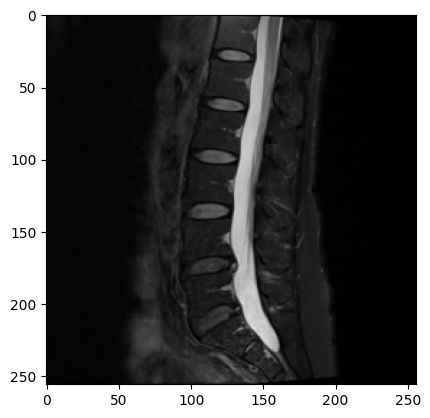

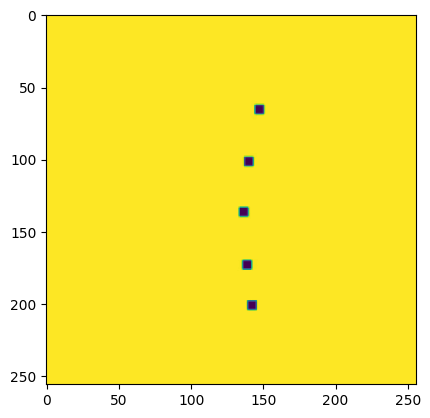

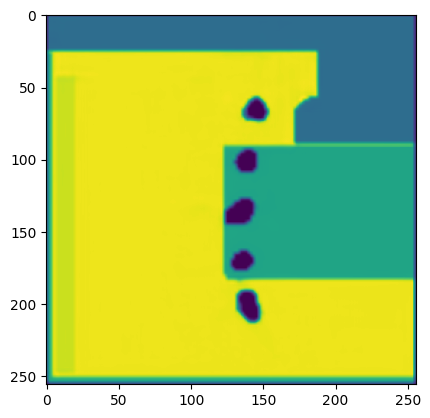

EPOCH: 0 LOSS_FSC: -1377.119384765625


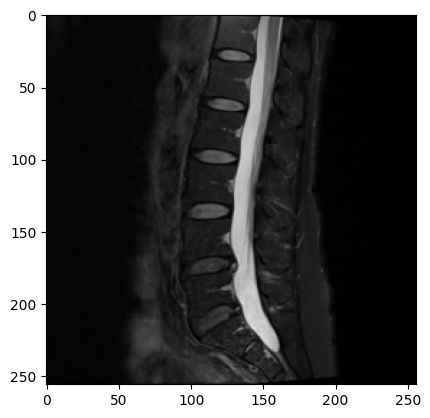

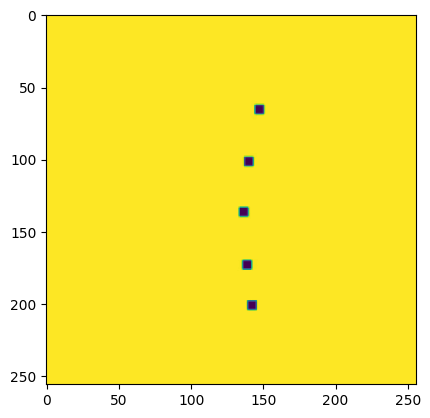

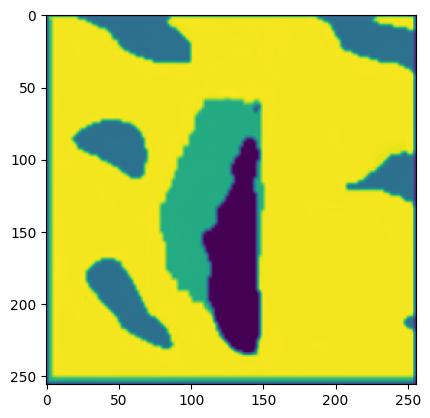

EPOCH: 1 LOSS_FSC: -4756.58740234375


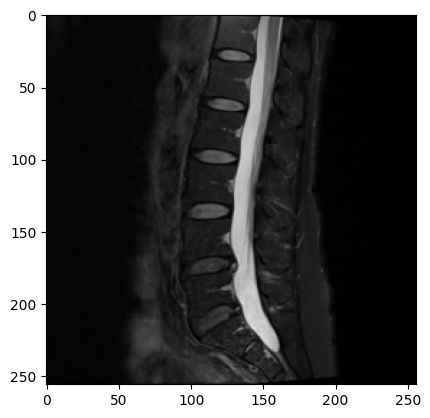

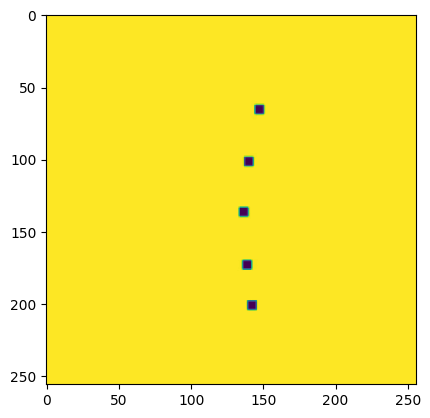

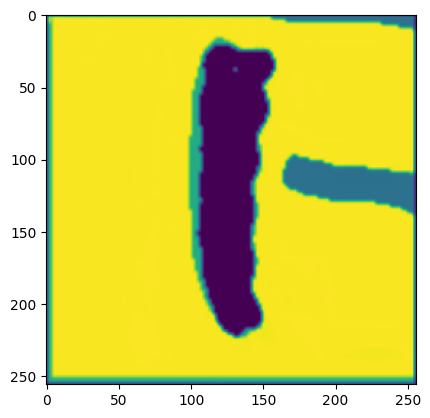

EPOCH: 2 LOSS_FSC: -9942.26171875


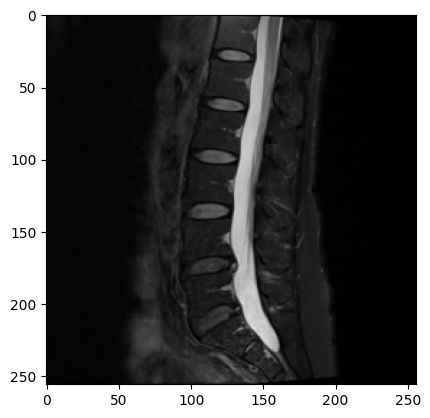

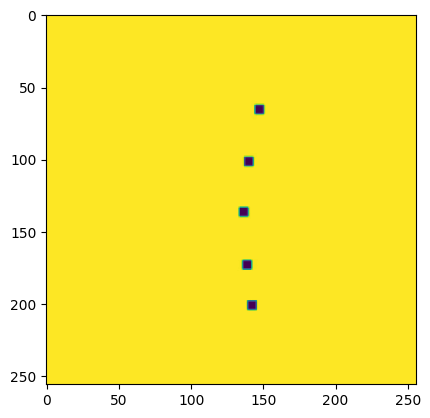

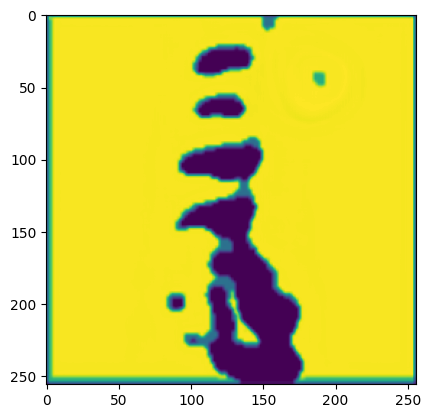

EPOCH: 3 LOSS_FSC: -16769.13671875


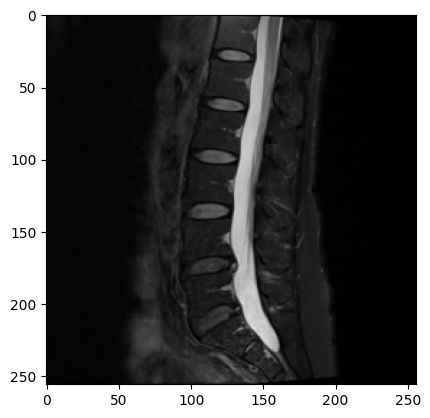

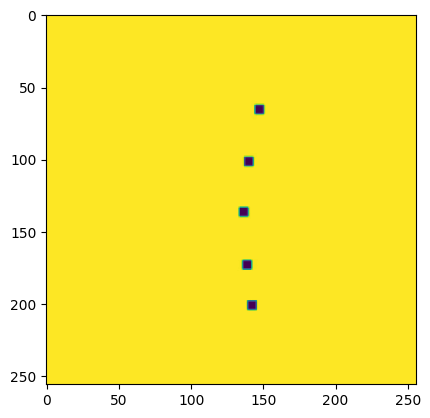

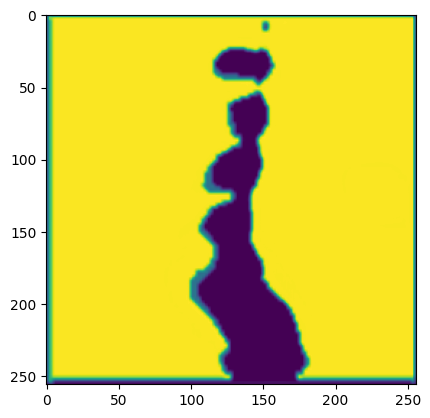

EPOCH: 4 LOSS_FSC: -25174.09765625


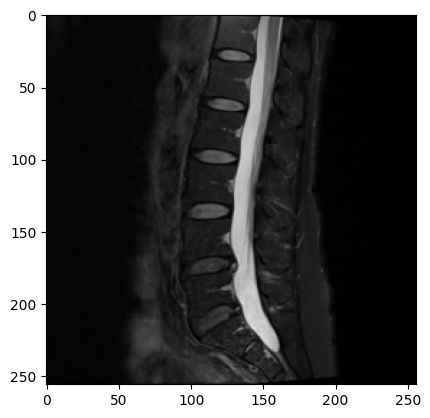

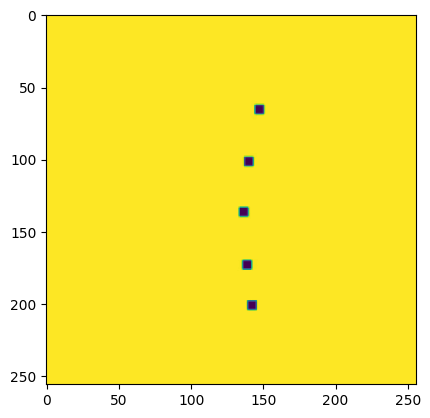

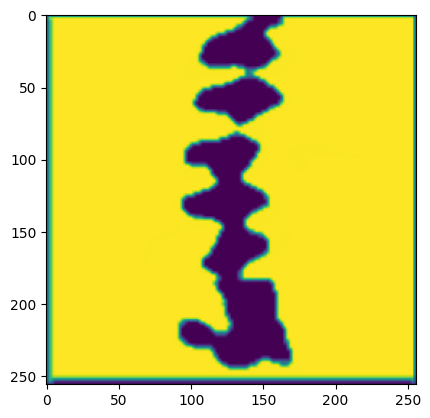

EPOCH: 5 LOSS_FSC: -34936.3359375


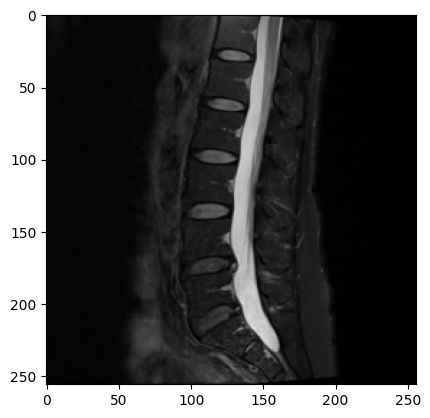

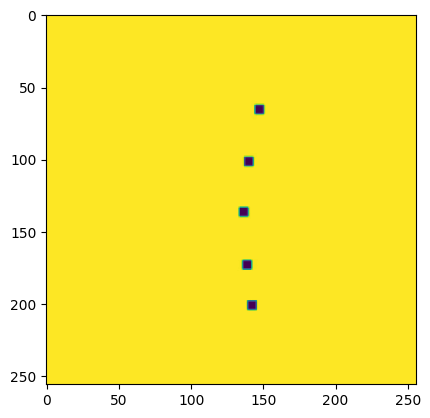

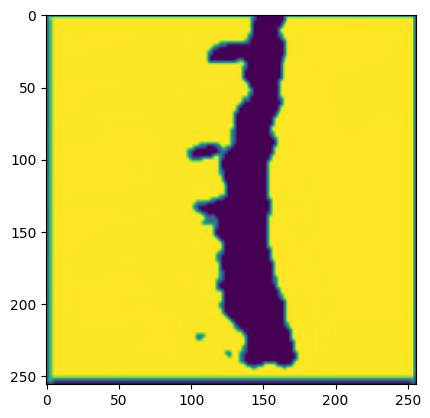

EPOCH: 6 LOSS_FSC: -45985.15234375


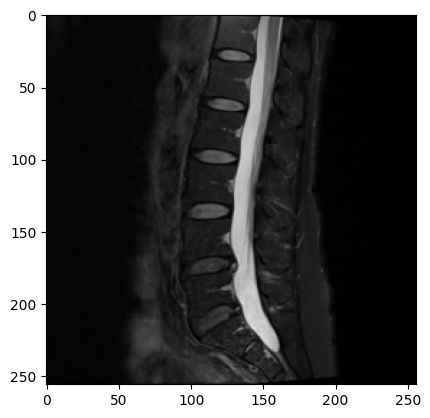

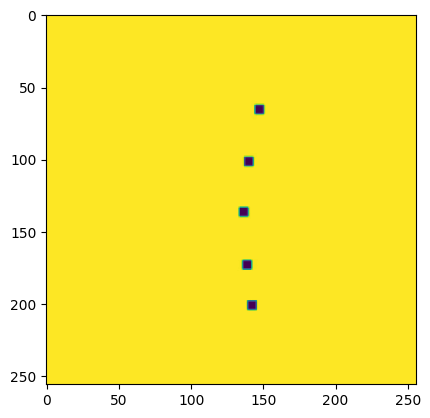

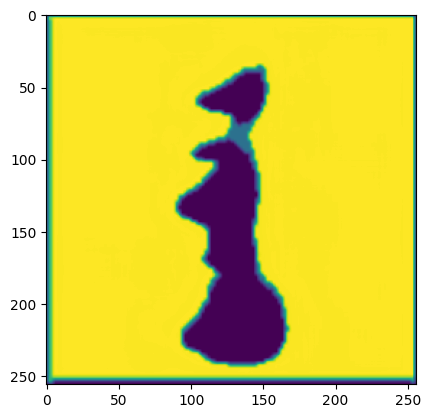

EPOCH: 7 LOSS_FSC: -58252.15234375


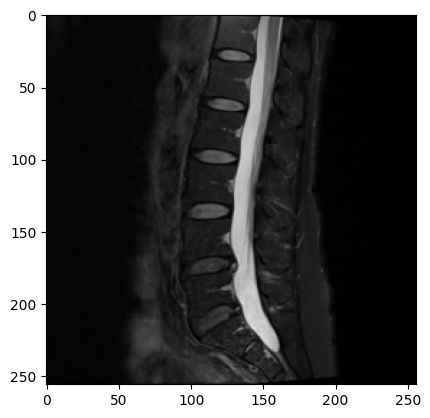

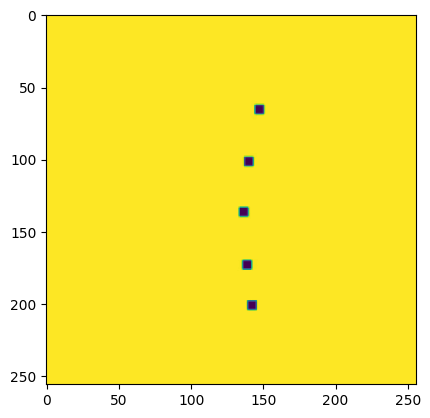

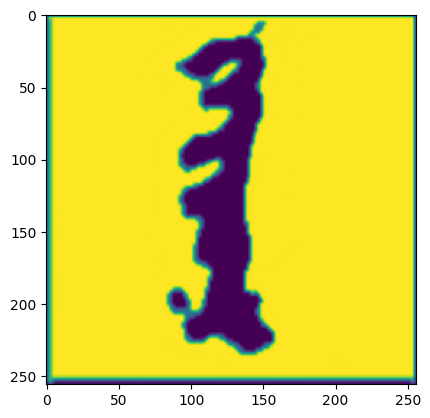

EPOCH: 8 LOSS_FSC: -71568.3125


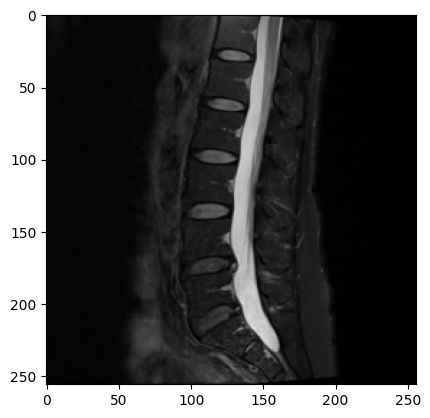

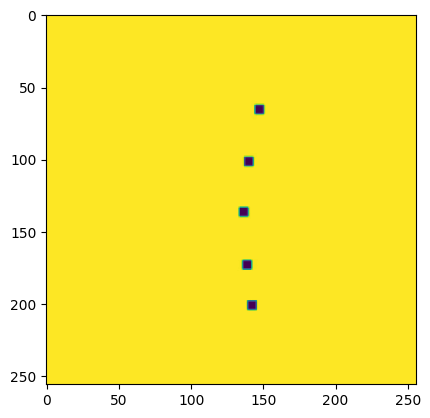

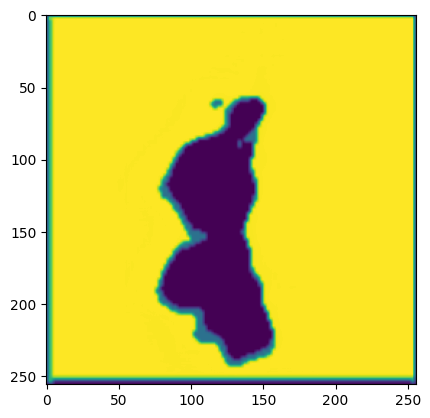

EPOCH: 9 LOSS_FSC: -85965.9296875


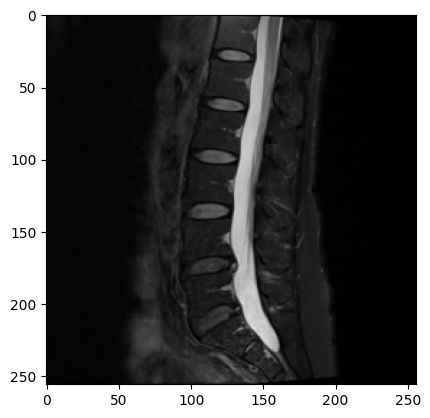

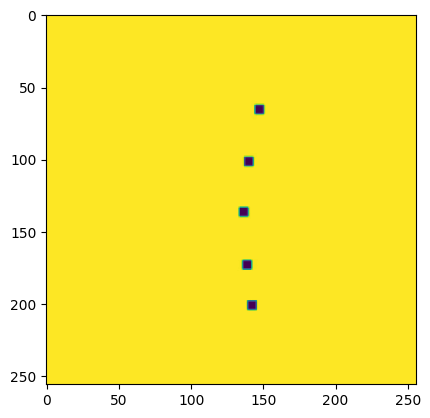

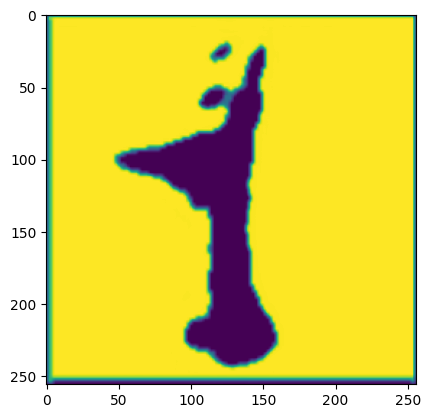

EPOCH: 10 LOSS_FSC: -101244.21875


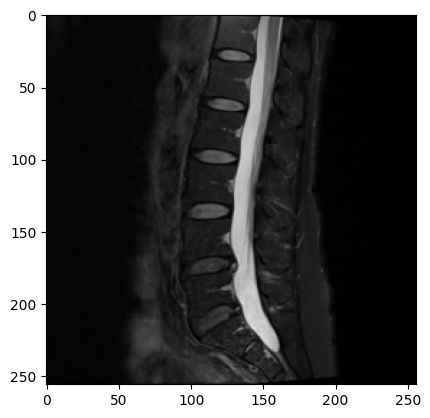

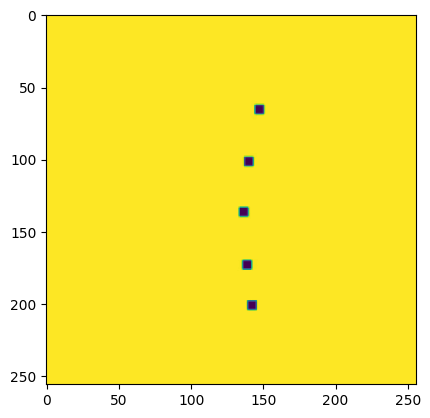

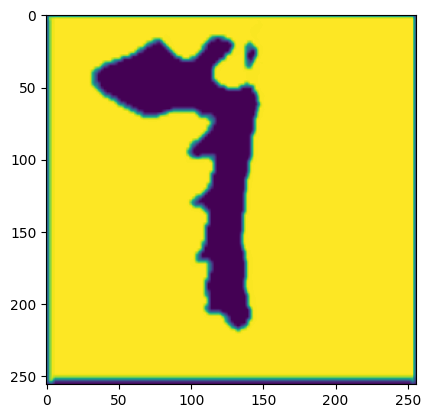

EPOCH: 11 LOSS_FSC: -117148.140625


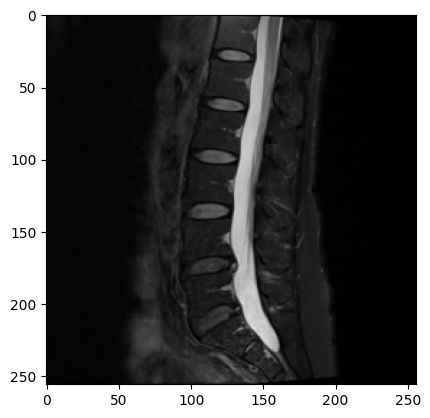

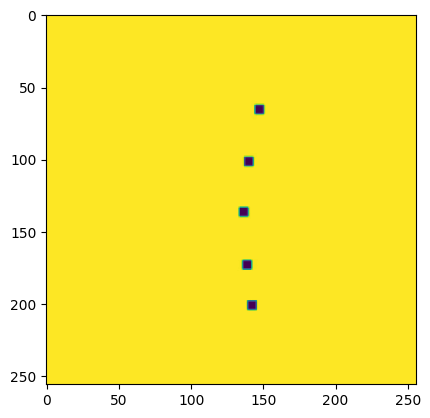

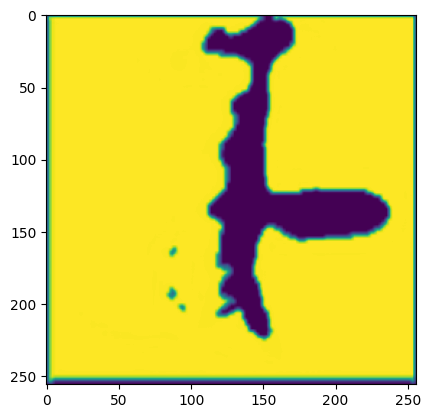

EPOCH: 12 LOSS_FSC: -134238.4375


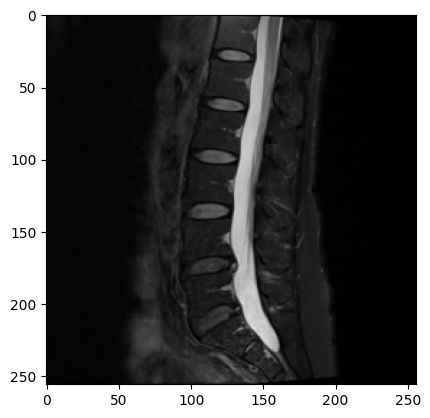

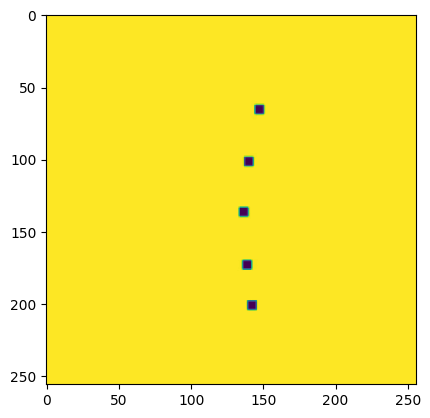

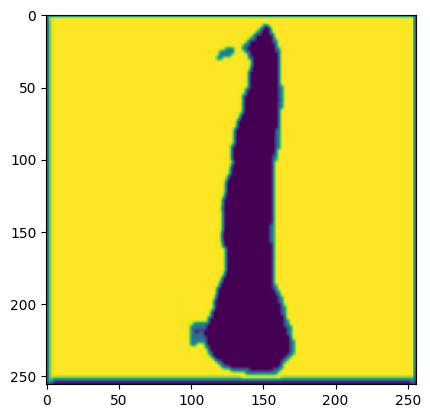

EPOCH: 13 LOSS_FSC: -151787.859375


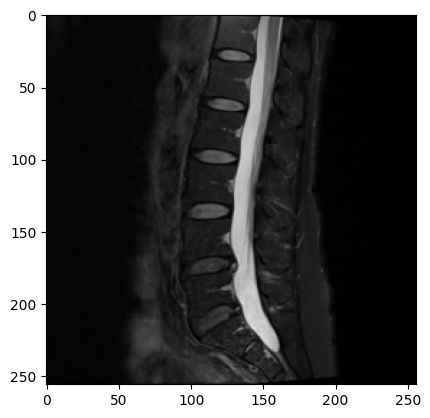

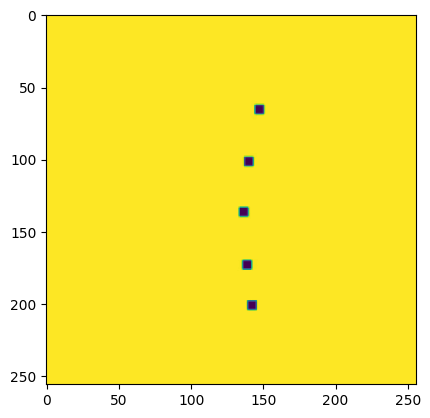

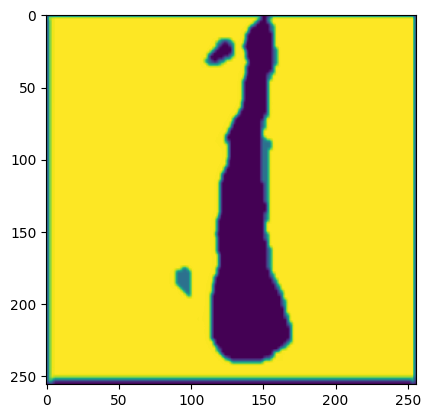

EPOCH: 14 LOSS_FSC: -169934.96875


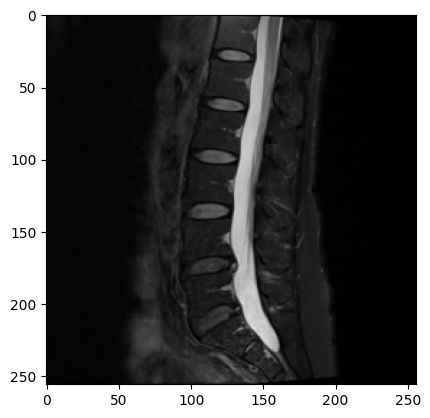

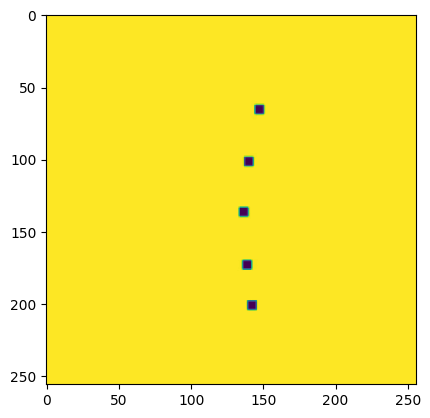

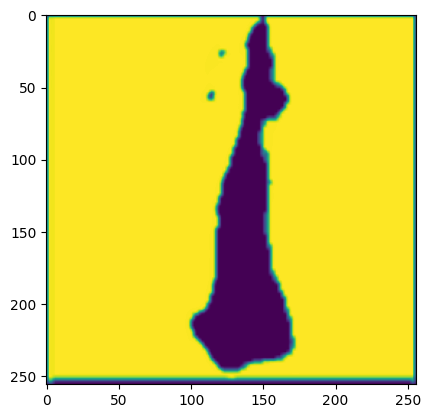

EPOCH: 15 LOSS_FSC: -188126.53125


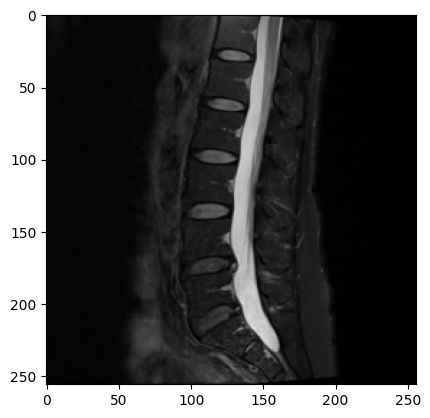

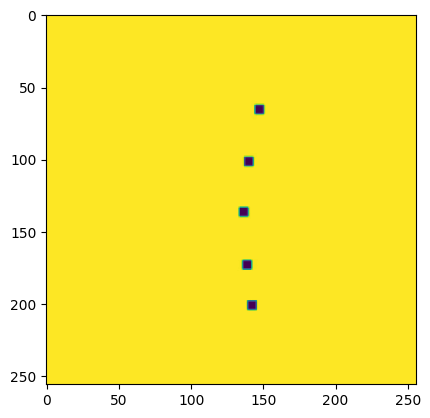

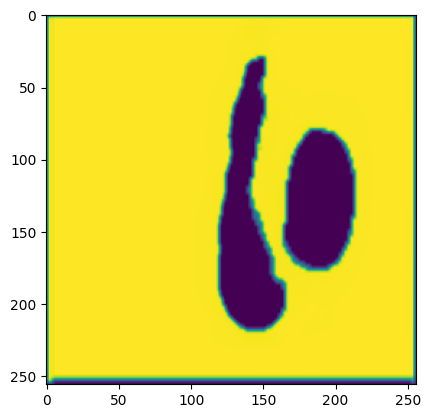

EPOCH: 16 LOSS_FSC: -206777.84375


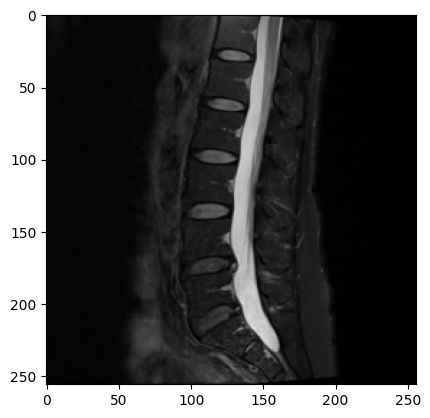

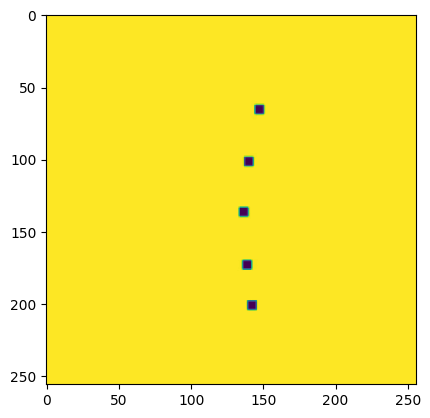

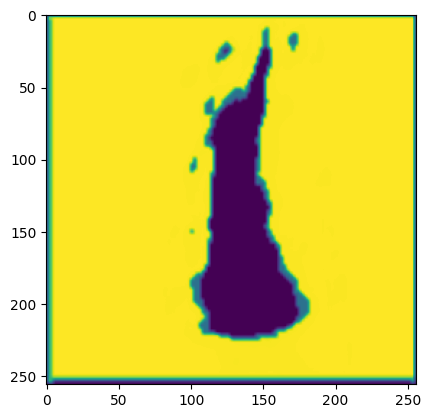

EPOCH: 17 LOSS_FSC: -226129.65625


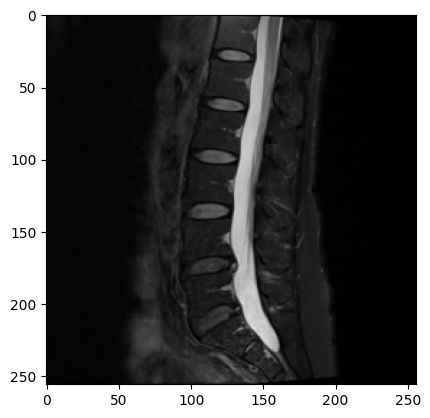

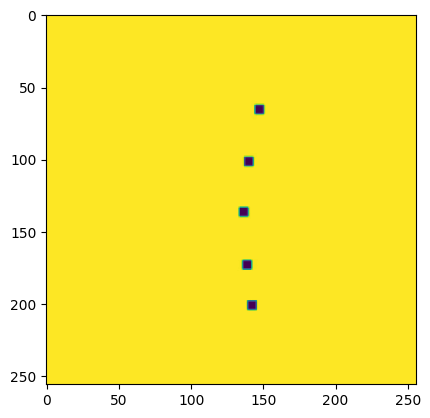

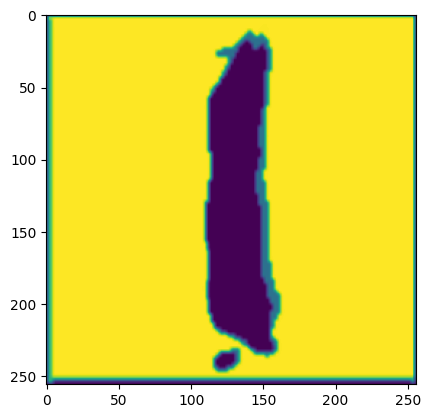

EPOCH: 18 LOSS_FSC: -245313.484375


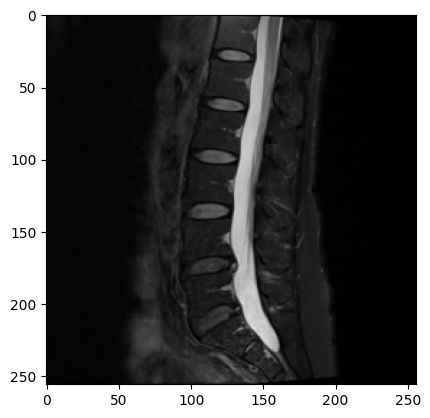

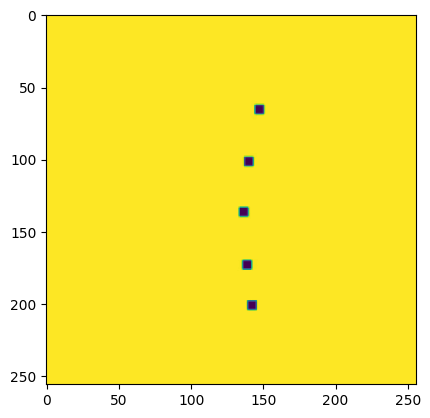

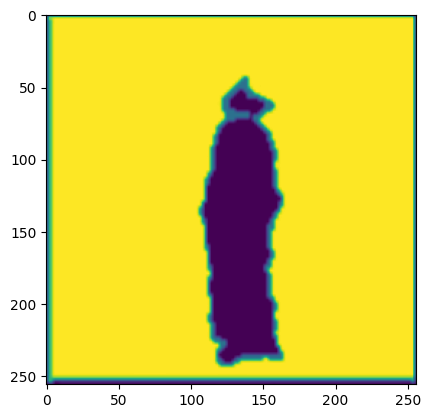

EPOCH: 19 LOSS_FSC: -265298.3125


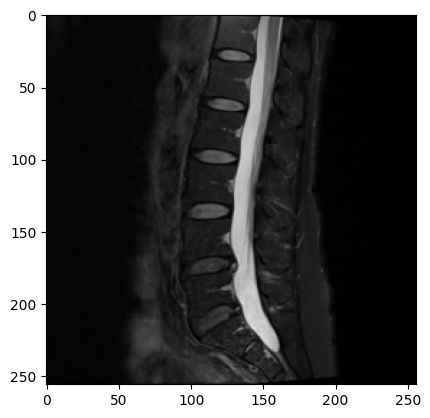

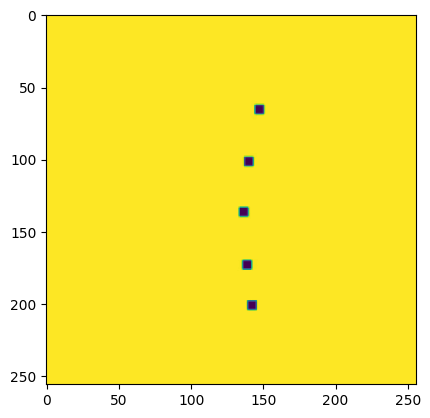

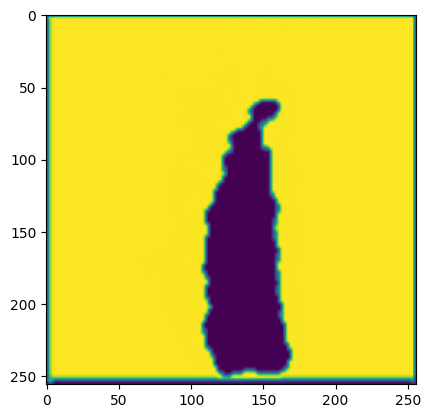

EPOCH: 20 LOSS_FSC: -285164.90625


In [9]:
cust = customiser()
cust.loss_optimizer()
cust.train(model)